In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns 

print('Librerías Cargadas')

Librerías Cargadas


In [2]:
df = pd.read_csv('../data/Churn_Modelling.csv')
print(df.shape)
df.head()

(10000, 14)


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [4]:
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [5]:
print(df['Exited'].value_counts())
print(df['Exited'].value_counts(normalize=True).round(2))

Exited
0    7963
1    2037
Name: count, dtype: int64
Exited
0    0.8
1    0.2
Name: proportion, dtype: float64


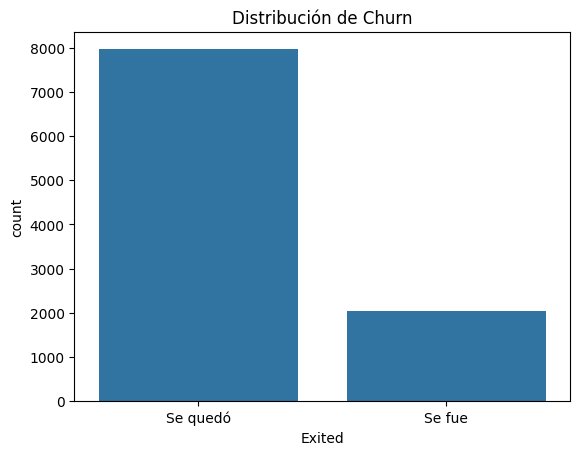

In [6]:
sns.countplot(x='Exited', data=df)
plt.title('Distribución de Churn')
plt.xticks([0, 1], ['Se quedó', 'Se fue'])
plt.show()

In [8]:
df.columns.tolist()

['RowNumber',
 'CustomerId',
 'Surname',
 'CreditScore',
 'Geography',
 'Gender',
 'Age',
 'Tenure',
 'Balance',
 'NumOfProducts',
 'HasCrCard',
 'IsActiveMember',
 'EstimatedSalary',
 'Exited']

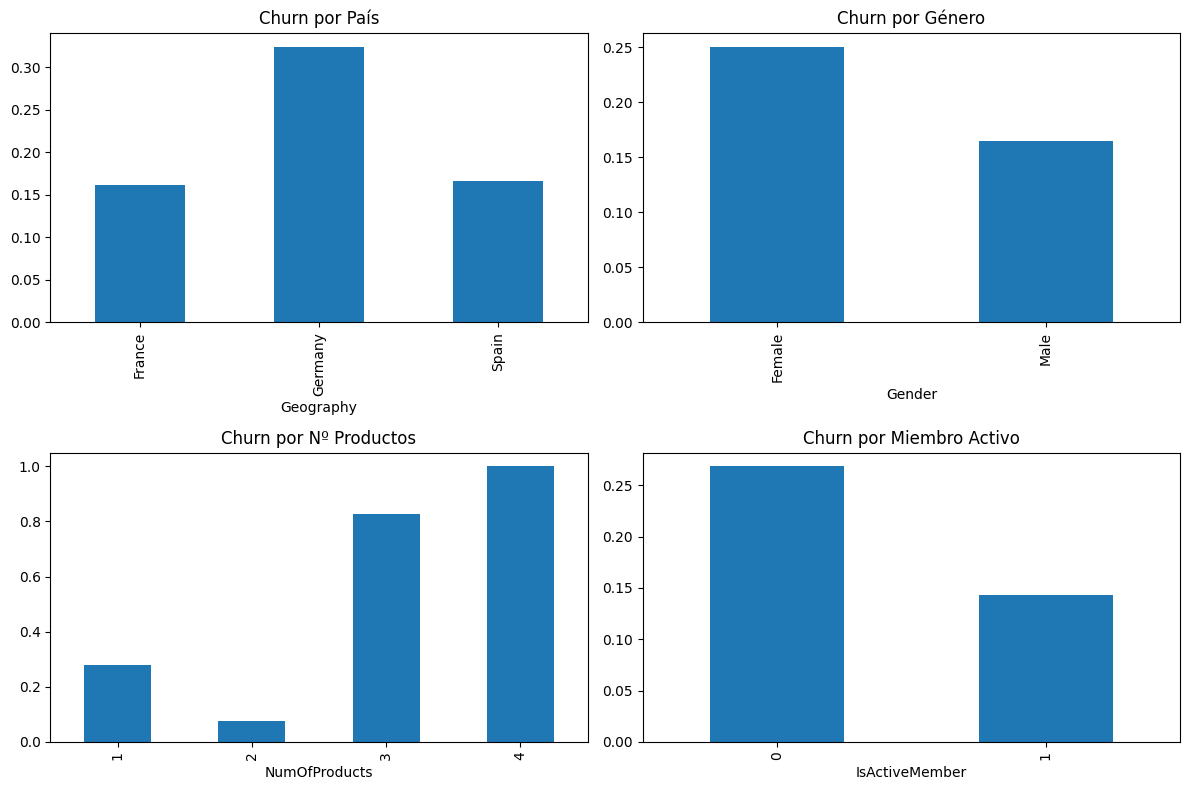

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

df.groupby('Geography')['Exited'].mean().plot(kind='bar', ax=axes[0,0], title='Churn por País')
df.groupby('Gender')['Exited'].mean().plot(kind='bar', ax=axes[0,1], title='Churn por Género')
df.groupby('NumOfProducts')['Exited'].mean().plot(kind='bar', ax=axes[1,0], title='Churn por Nº Productos')
df.groupby('IsActiveMember')['Exited'].mean().plot(kind='bar', ax=axes[1,1], title='Churn por Miembro Activo')

plt.tight_layout()
plt.show()

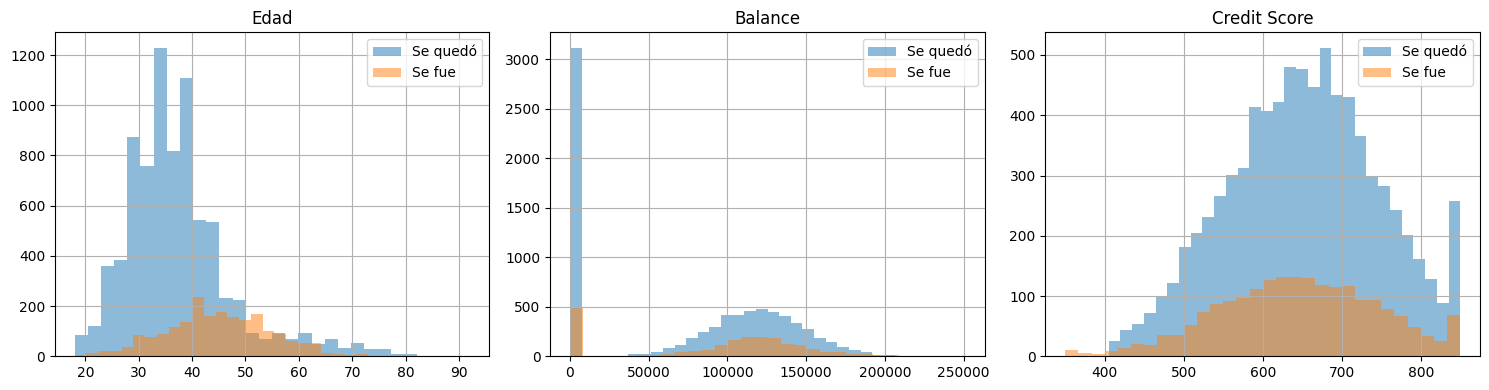

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

df[df['Exited']==0]['Age'].hist(ax=axes[0], alpha=0.5, label='Se quedó', bins=30)
df[df['Exited']==1]['Age'].hist(ax=axes[0], alpha=0.5, label='Se fue', bins=30)
axes[0].set_title('Edad')
axes[0].legend()

df[df['Exited']==0]['Balance'].hist(ax=axes[1], alpha=0.5, label='Se quedó', bins=30)
df[df['Exited']==1]['Balance'].hist(ax=axes[1], alpha=0.5, label='Se fue', bins=30)
axes[1].set_title('Balance')
axes[1].legend()

df[df['Exited']==0]['CreditScore'].hist(ax=axes[2], alpha=0.5, label='Se quedó', bins=30)
df[df['Exited']==1]['CreditScore'].hist(ax=axes[2], alpha=0.5, label='Se fue', bins=30)
axes[2].set_title('Credit Score')
axes[2].legend()

plt.tight_layout()
plt.show()

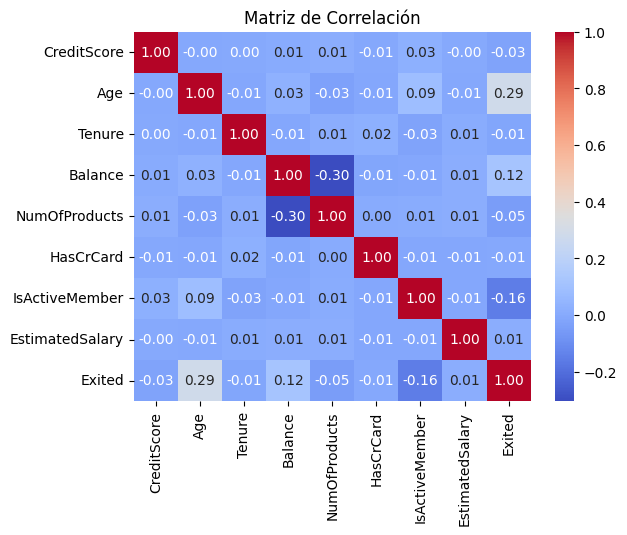

In [11]:
corr_cols = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 
             'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']

sns.heatmap(df[corr_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Matriz de Correlación')
plt.show()